In [1]:
# imports des bibliothèques
import torch
import torch.nn as nn

import os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("BASE_DIR :", BASE_DIR)

import pickle as pkl

import numpy as np
import pandas as pd
import random as rd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

BASE_DIR : /home/lauronta/Bureau/IODAA/iodaa/Projet_fil_rouge/projet_fil_rouge_afz


In [2]:
os.chdir(BASE_DIR)
import models_raph
from models_raph import basic
from pathlib import Path
import utils

import sys

from utils import deep_models

sys.modules["deep_models"] = deep_models

os.chdir(BASE_DIR)

'''
path_model_fnv_with_bert_base_uncased_10 = Path('models_raph/basic/fnv_with_bert-base-uncased_10.pth').resolve()
print(path_model_fnv_with_bert_base_uncased_10)

with open(str(path_model_fnv_with_bert_base_uncased_10), 'rb') as f:
    model = torch.load(f, map_location=torch.device('cpu'), weights_only=False)
    print("model keys :", model.keys())
'''

'\npath_model_fnv_with_bert_base_uncased_10 = Path(\'models_raph/basic/fnv_with_bert-base-uncased_10.pth\').resolve()\nprint(path_model_fnv_with_bert_base_uncased_10)\n\nwith open(str(path_model_fnv_with_bert_base_uncased_10), \'rb\') as f:\n    model = torch.load(f, map_location=torch.device(\'cpu\'), weights_only=False)\n    print("model keys :", model.keys())\n'

In [3]:
from transformers import AutoModel
from deep_models import FNVModel


llm = AutoModel.from_pretrained('google-bert/bert-base-uncased')

model = FNVModel.from_pretrained('models_raph/basic/fnv_with_bert-base-uncased_10',llm = llm ,device='cpu')

/home/lauronta/miniconda3/envs/pfr_fourrage/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded successfully from models_raph/basic/fnv_with_bert-base-uncased_10


In [ ]:
state_dict = model

In [14]:
enricher = state_dict.repr_enricher[0].weight
enricher.shape

torch.Size([2048, 774])

In [6]:
for key, value in state_dict.items():
    print(f"Layer: {key}", "\n", f"Shape: {value.shape}")

AttributeError: 'FNVModel' object has no attribute 'items'

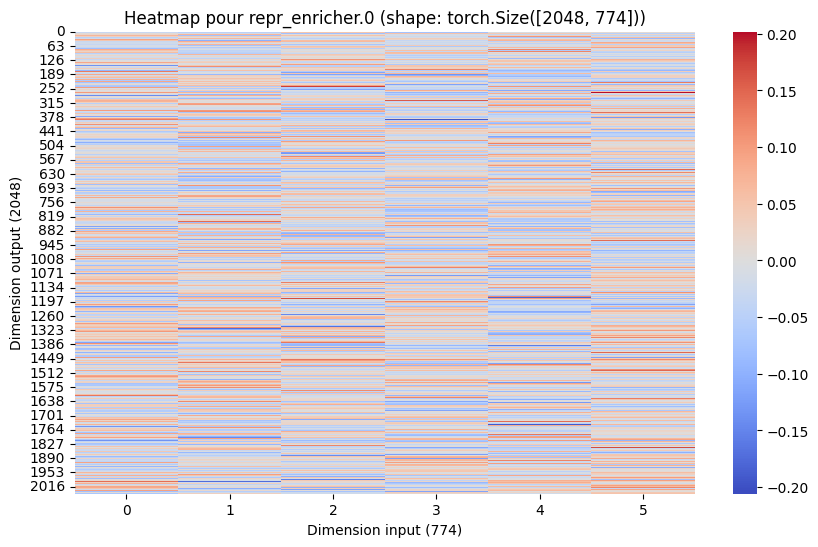

(6,)
(2048, 774)


/tmp/ipykernel_7850/1452499118.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_7850/1452499118.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


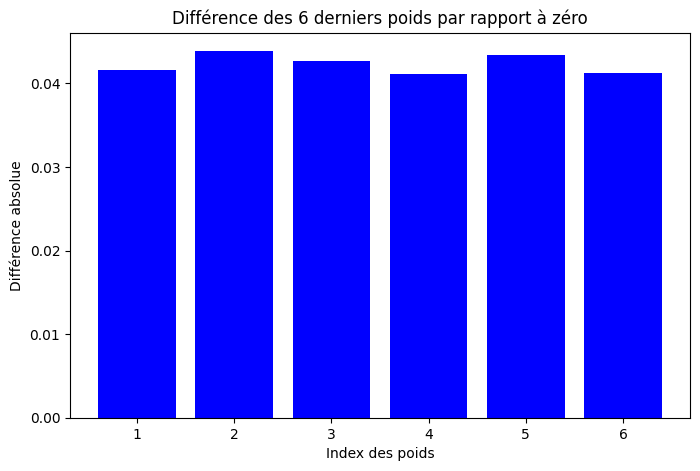

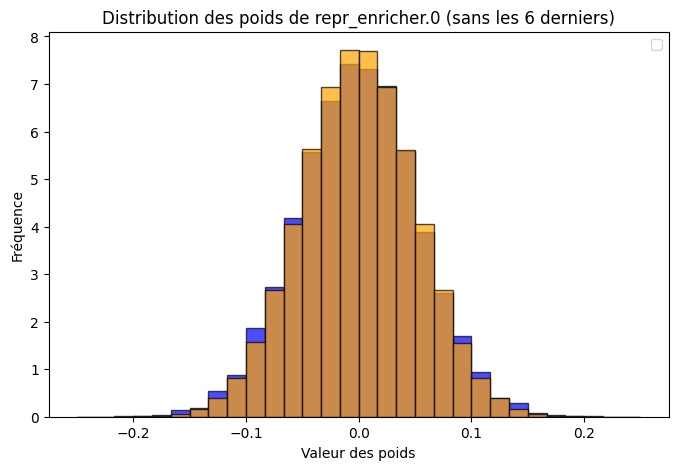

In [21]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  # Importation de numpy pour utiliser np.abs()

# Liste des couches de poids à afficher (on retire les biais)
layers_weights = [
    #"feature_extractor.pooler.dense.weight",
    "repr_enricher.0.weight",
    #"repr_enricher.2.weight",
    #"repr_enricher.5.weight",
    #"regressor.0.weight",
    #"regressor.2.weight",
    #"regressor.5.weight",
    #"regressor.7.weight"
]

tensor = enricher
# Parcourir la liste et afficher la heatmap de chaque couche de poids
#for layer in layers_weights:
    # Extraire le tenseur depuis le state_dict
#    tensor = state_dict[layer]
    
tensor_np_his = None  # Initialisation de tensor_np_his à None
layer = 'repr_enricher.0'
#if layer == "repr_enricher.0.weight":
    # Pour repr_enricher.0.weight, on sélectionne les 6 derniers poids de la première dimension
chemical_weights = tensor.cpu().detach().numpy()[:,-6:]
textual_weights = tensor.cpu().detach().numpy()[:,:-6]
tensor_np_his = np.mean(np.abs(tensor.cpu().detach().numpy()[:,-6:]), 0)  # Utilisation de np.abs() pour numpy
    
'''    
else:
    # Sinon, on convertit tout le tensor en numpy
    chemical_weights = tensor.cpu().detach().numpy()
'''

# Création de la heatmap pour ce tenseur
plt.figure(figsize=(10, 6))
sns.heatmap(chemical_weights, cmap="coolwarm", center=0)
plt.title(f"Heatmap pour {layer} (shape: {tensor.shape})")
plt.ylabel(f"Dimension output ({tensor.shape[0]})")
plt.xlabel(f"Dimension input ({tensor.shape[1]})")
plt.show()

# Création de l'histogramme si nécessaire
if tensor_np_his is not None:
    
    plt.figure(figsize=(8, 5))
    print(tensor_np_his.shape)
    plt.bar(range(1, 7), tensor_np_his.flatten(), color='blue')  # Utilisation de flatten pour aplatir le tensor
    plt.title('Différence des 6 derniers poids par rapport à zéro')
    plt.xlabel('Index des poids')
    plt.ylabel('Différence absolue')
    
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot()
    st = np.hstack((chemical_weights, textual_weights))
    print(st.shape)
    ax.hist(chemical_weights.flatten(), histtype='bar', bins=30, range=(-0.25, 0.25), color='blue', density=True, edgecolor='black', alpha=0.7)
    ax.hist(textual_weights.flatten(), histtype='bar',  bins=30, range=(-0.25, 0.25), color='orange',density=True, edgecolor='black', alpha=0.7)
    plt.legend()
    ax.set_title(f'Distribution des poids de {layer} (sans les 6 derniers)')
    ax.set_xlabel('Valeur des poids')
    ax.set_ylabel('Fréquence')
    fig.show()
